# Pre-processing (Re-annotation)

## Foreword

`dandelion` is written in `Python 3` and is a single-cell BCR/TCR V(D)J-seq analysis package. For the pre-processing section, it integrates a standard pipeline for V(D)J gene reannotation with `IgBLAST`, similar to the fantastic [immcantation suite](https://immcantation.readthedocs.io/) [[Gupta2015]](https://academic.oup.com/bioinformatics/article/31/20/3356/195677). This work streamlines the pre-processing and exploratory stages for analyzing single-cell BCR/TCR V(D)J-seq data from 10X Genomics (and other technologies as long as they can be formatted or read into `dandelion` accordingly). Post-processed data from `dandelion` can be smoothly transferred to [scirpy](https://scirpy.scverse.org/)[Sturm2020](https://academic.oup.com/bioinformatics/article/36/18/4817/5866543) and [Scanpy](https://scanpy.readthedocs.io/)/[AnnData](https://anndata.readthedocs.io/) [[Wolf2018]](https://doi.org/10.1186/s13059-017-1382-0) object for integration and exploration of scV(D)J-seq data and scRNA-seq data. 

For some of the more advanced scV(D)J-seq analysis, specifically V(D)J trajectory analysis, there's also an `R` package `dandelionR` [Yu2024](https://doi.org/10.1016/j.csbj.2025.06.047) available on [GitHub](https://github.com/tuonglab/dandelionR) and [BioConductor](https://bioconductor.org/packages/release/bioc/html/dandelionR.html). If you are an `R` user and you want to perform pre-processing and re-annotation of your single-cell V(D)J-seq data, please refer to the `immcantation` suite and its documentation. Alternatively, there is a [singularity container](https://sc-dandelion.readthedocs.io/en/latest/notebooks/Q1-singularity-preprocessing.html) that can automate the steps outlined below.

<div class="alert alert-info">

Note
    
This section will cover the initial pre-processing of files after 10X's `CellRanger vdj` immune profiling data analysis (BCR) pipeline manually.

</div>

In [1]:
# Import modules
import dandelion as ddl

# Set backend to "base" for the purpose of this tutorial as my environment already has polars installed so the default backend is polars. You can set the backend to "base" to use pandas instead.
ddl.set_backend("base")

ddl.logging.print_versions()

dandelion==1.0.0a1.dev36 pandas==2.3.3 numpy==2.3.5 matplotlib==3.10.6 networkx==3.6.1 scipy==1.15.2


We will download the 10X data sets to process for this tutorial. The following function will download the tutorial files and place them in a folder called `dandelion_tutorial` in your current working directory.


In [2]:
# new function to setup tutorial data
from dandelion.tutorial import setup_dandelion_tutorial_bcr

setup_dandelion_tutorial_bcr()

# change to the tutorial data directory
import os

os.chdir("dandelion_tutorial")

`Dandelion`'s reannotation workflow requires `CellRanger` formatted-files to start, particularly either `all_contig.fasta` or `filtered_contig.fasta` and corresponding `all_contig_annotations.csv` and `filtered_contig_annotations.csv`. If you only have an `AIRR` rearrangement file, you can still load it into `dandelion` and write the files out with `.write_10x` function later.

I'm running everything with the `filtered` files to speed up the tutorial but I would recommend starting with the `all` files as they contain more information, and it is easier to filter the contigs than to try and add them back in later.

If you followed the installation instructions, you should have the requisite auxillary softwares installed already. Otherwise, you can download them manually: [blast+](https://ftp.ncbi.nih.gov/blast/executables/igblast/release/LATEST/) and [igblast](https://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/LATEST/).

For convenience, in `shell`, export the path to the database folders like as follows:
```bash
# ~/.bash_profile or ~/.bashrc if using bash or ~/.zshrc if you are using zsh
echo "export GERMLINE=$HOME/Documents/Github/dandelion/container/database/germlines/" >> ~/.bash_profile
echo "export IGDATA=$HOME/Documents/Github/dandelion/container/database/igblast/" >> ~/.bash_profile
echo "export BLASTDB=$HOME/Documents/Github/dandelion/container/database/blast/" >> ~/.bash_profile
source ~/.bash_profile
```

The databases for igblast are basically setup using [changeo's instructions](https://changeo.readthedocs.io/en/stable/examples/igblast.html). 

If you are using a jupyter notebook initialized via jupyterhub instance, you might want to try the fix to a known issue where pathing requires some adjustments https://github.com/zktuong/dandelion/discussions/146.

For reannotation of constant genes, reference fasta files were downloaded from IMGT and only sequences corresponding to *CH1* region for each constant gene/allele were retained. The headers were trimmed to only keep the gene and allele information. Links to find the sequences can be found here : [human](http://www.imgt.org/genedb/GENElect?query=7.2+IGHC&species=Homo+sapiens) and [mouse](http://www.imgt.org/genedb/GENElect?query=7.2+IGHC&species=Mus).

The utility function `ddl.utl.makeblastdb` is a wrapper for:

```bash
# bash/shell
makeblastdb -dbtype nucl -parse_seqids -in $BLASTDB/human/human_BCR_C.fasta
```

This does the same thing:
```python
# python
ddl.utl.makeblastdb(os.path.expanduser("~/Documents/Github/dandelion/container/database/blast/human/human_BCR_C.fasta")
```

This section will now demonstrate how I batch process multiple samples/files from the same donor, as it will become important later on.

Finally, because you are running the preprocessing manually, you will need to install some R packages so that they work later:

```R
install.packages(c("optparse", "airr", "shazam", "alakazam", "tigger"))
```

## Step 1: Formatting the headers of the Cell Ranger fasta file
Here, I'm adding a prefix to the headers of each contig in the fasta files, via the function `pp.format_fastas`. The prefix is basically just the folder name, so in this case it's:
`sc5p_v2_hs_PBMC_1k`, `sc5p_v2_hs_PBMC_10k`, `vdj_v1_hs_pbmc3` and `vdj_nextgem_hs_pbmc3`.

The function will also create sub-folders where a new fasta file and all subsequent files will be located. The function will also add the prefix to the corresponding annotation file automatically and create a copy in the same folder as the formatted fasta file. 

This is to ensure that the barcodes are consistent throughout so as not to interfere with subsequent integration with the gene expression data, which will be covered in subsequent sections. 

The file structure should look something like this later on if the settings are left as default. The tmp directory can be deleted once the initial preprocessing has completed.
```console
sc5p_v2_hs_PBMC_1k
├── dandelion
│   ├── filtered_contig.fasta
│   ├── filtered_contig_annotations.csv
│   ├── filtered_contig_igblast_db-pass_genotyped.tsv
│   └── tmp
│       ├── filtered_contig_igblast.fmt7
│       ├── filtered_contig_igblast.tsv
│       ├── filtered_contig_igblast_db-pass.blastsummary.txt
│       ├── filtered_contig_igblast_db-pass.tsv
│       ├── filtered_contig_igblast_db-pass.xml
│       ├── filtered_contig_igblast_db-pass_genotyped.tsv
│       ├── filtered_contig_igblast_db-pass_heavy_parse-select.tsv
│       └── filtered_contig_igblast_db-pass_light_parse-select.tsv
├── filtered_contig.fasta
├── filtered_contig_annotations.csv
└── filtered_feature_bc_matrix.h5
```

The first option of `pp.format_fastas` accepts a list of the fasta file paths to reformat, or list of names of folders containing the fasta files; each folder should only contain 1 fasta file, and 1 contig_annotation.csv. Make sure there's no hidden files and delete those if present.

You can provide `prefixes` and/or `suffixes` to add the the cell/contig barcodes as a list and they will be formatted accordingly. The prefixes/suffixes will be separated by an underscore (`_`) if left as default but that can be adjusted with the `sep` option. 

If you choose not to provide a prefix/suffix, then the function will simply make a copy of the original files and place it in the `dandelion` sub-folders.

For more complex experimental setups, such as with data from multiplexed experiments, please contact me (z.tuong@uq.edu.au) and I can walk you through a slightly more advanced set up.

In [3]:
# the first option is a list of fasta files to format and the second option is the list of prefix to add to each file.
samples = [
    "sc5p_v2_hs_PBMC_1k_b",
    "sc5p_v2_hs_PBMC_10k_b",
    "vdj_v1_hs_pbmc3_b",
    "vdj_nextgem_hs_pbmc3_b",
]
# because I'm using the 'filtered' files, i need to specify the filename_prefix
ddl.pp.format_fastas(samples, prefix=samples, filename_prefix="filtered")

Formatting fasta(s) : 100%|██████████| 4/4 [00:00<00:00,  7.55it/s]


Please specify the `filename_prefix` option for all preprocessing functions below (except for `quantify_mutations`).

For example, use `filename_prefix="all"` for `all_contig.fasta`, or `filename_prefix=<insertprefix>` for any files that are named `<insertprefix>_contig.fasta`. 

If you are running more than 1 sample and if each filename prefix needs to be specified, `filename_prefix` in `ddl.pp.format_fastas` will accept a list of prefixes i.e. `filename_prefix=['all', 'filtered', ...]`.


## Step 2: Reannotate the V/D/J genes with *igblastn*

Like immcantation, we will reannotate the V(D)J genes with igblastn using the latest IMGT reference databases. Dandelion's `pp.reannotate_genes` will use `flavour="strict"` to run `igblastn`, imposing lower e-value and higher D-penalty cut offs. The original behaviour i.e. with [changeo](https://changeo.readthedocs.io/en/stable/examples/10x.html)'s `AssignGenes.py`, is toggled with `flavour="original"`. Additionally, there is now an additional `assign_dj` option (default is `True`), which will use blastn to assign a stricter call for the D and J genes because [igblastn can return random assignments if it cannot detect a V gene](https://www.ncbi.nlm.nih.gov/igblast/faq.html). In the `tmp` folder, there will also be a table where all alignments generated in this step will be shown. All the column headers are now adhering to the [AIRR](http://docs.airr-community.org/) standard.

In [4]:
ddl.pp.reannotate_genes(samples, filename_prefix="filtered")

Assigning genes :   0%|          | 0/4 [00:00<?, ?it/s]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 13:29:22 |Done                | 0.0 min

PROGRESS> 13:29:23 |####################| 100% (202) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 185
  FAIL> 17
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 13:29:24 |Done                | 0.0 min

PROGRESS> 13:29:25 |####################| 100% (202) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 185
  FAIL> 17
   END> MakeDb



Assigning genes :  25%|██▌       | 1/4 [00:15<00:45, 15.12s/it]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 13:30:14 |Done                | 0.0 min

PROGRESS> 13:30:15 |####################| 100% (2,601) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 2413
  FAIL> 188
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 13:30:16 |Done                | 0.0 min

PROGRESS> 13:30:17 |####################| 100% (2,601) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 2413
  FAIL> 188
   END> MakeDb



Assigning genes :  50%|█████     | 2/4 [01:10<01:17, 38.80s/it]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 13:30:55 |Done                | 0.0 min

PROGRESS> 13:30:56 |####################| 100% (2,059) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 1853
  FAIL> 206
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 13:30:57 |Done                | 0.0 min

PROGRESS> 13:30:58 |####################| 100% (2,059) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 1853
  FAIL> 206
   END> MakeDb



Assigning genes :  75%|███████▌  | 3/4 [01:50<00:39, 39.43s/it]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 13:31:52 |Done                | 0.0 min

PROGRESS> 13:31:54 |####################| 100% (3,222) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 2991
  FAIL> 231
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 13:31:54 |Done                | 0.0 min

PROGRESS> 13:31:56 |####################| 100% (3,222) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 2991
  FAIL> 231
   END> MakeDb



Assigning genes : 100%|██████████| 4/4 [02:49<00:00, 42.45s/it]


<div class="alert alert-info">

Note

If you did not set a path to the igblast or germline paths in the environment above, you need to specify the path to the folders containing the fasta files directly.

```python
ddl.pp.reannotate_genes(samples, 
    igblast_db="database/igblast/",
    germline="database/germlines/imgt/human/vdj/")
```
</div>

## Step 3 : Reassigning heavy chain V gene alleles *(optional but recommended)*

Next, we use `immcantation`'s `TIgGER` [[Gadala-Maria2015]](https://www.pnas.org/content/112/8/E862) method to reassign allelic calls for heavy chain V genes with `pp.reassign_alleles`. As stated in TIgGER's [website](https://tigger.readthedocs.io/en/stable/) and [manuscript](https://www.pnas.org/content/112/8/E862), *'TIgGER is a computational method that significantly improves V(D)J allele assignments by first determining the complete set of gene segments carried by an individual (including novel alleles) from V(D)J-rearrange sequences. TIgGER can then infer a subject’s genotype from these sequences, and use this genotype to correct the initial V(D)J allele assignments.'*

This may impact on how contigs are chosen for finding clones later. It is also important when considering to do mutational analysis. For convenience, germline sequences are reconstructed at this step using the corrected V-gene alleles. Therefore, it is highly recommended to run it. 

However, this will only work properly if there is sufficient contigs. An ideal scenario would be to run it on multiple samples from the same subject to allow for more information to be used to confidently assign a genotyped *v_call*. In this tutorial, I'm assuming the four samples can be split into two sets where sets of two corresponds to a different/single individual. So while important, this step can be skipped if you don't have enough data to do this. 

`pp.reassign_alleles` requires the `combined_folder` option to be specified so that a merged/concatenated file can be produced for running TIgGER.

Processing data file(s) :   0%|          | 0/2 [00:00<?, ?it/s]

  START> ParseDb
COMMAND> select
   FILE> filtered_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IGH
  REGEX> True

PROGRESS> 13:32:03 |####################| 100% (185) 0.0 min

   OUTPUT> filtered_contig_igblast_db-pass_heavy_parse-select.tsv
  RECORDS> 185
 SELECTED> 89
DISCARDED> 96
      END> ParseDb



Processing data file(s) :  50%|█████     | 1/2 [00:00<00:00,  1.49it/s]

  START> ParseDb
COMMAND> select
   FILE> filtered_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IG[LK]
  REGEX> True

PROGRESS> 13:32:03 |####################| 100% (185) 0.0 min

   OUTPUT> filtered_contig_igblast_db-pass_light_parse-select.tsv
  RECORDS> 185
 SELECTED> 96
DISCARDED> 89
      END> ParseDb

  START> ParseDb
COMMAND> select
   FILE> filtered_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IGH
  REGEX> True

PROGRESS> 13:32:03 |####################| 100% (2,413) 0.0 min

   OUTPUT> filtered_contig_igblast_db-pass_heavy_parse-select.tsv
  RECORDS> 2413
 SELECTED> 1135
DISCARDED> 1278
      END> ParseDb



Processing data file(s) : 100%|██████████| 2/2 [00:01<00:00,  1.37it/s]

  START> ParseDb
COMMAND> select
   FILE> filtered_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IG[LK]
  REGEX> True

PROGRESS> 13:32:04 |####################| 100% (2,413) 0.0 min

   OUTPUT> filtered_contig_igblast_db-pass_light_parse-select.tsv
  RECORDS> 2413
 SELECTED> 1278
DISCARDED> 1135
      END> ParseDb

      Reassigning alleles



Error in findNovelAlleles(db, germline_db = igv, v_call = v_call, j_call = j_call,  : 
  Not enough sample sequences were assigned to any germline:
  (1) germline_min is too large or
  (2) sequences names don't match germlines.
Execution halted
ERROR> Database file /Users/uqztuong/Documents/GitHub/dandelion/docs/notebooks/base/dandelion_tutorial/tutorial_scgp1/tutorial_scgp1_heavy_igblast_db-pass_genotyped.tsv does not exist.



      Reassigning alleles


Reverting 18 sequence(s) whose V gene family is absent from the inferred genotype.


null device 
          1 
     START> CreateGermlines
      FILE> tutorial_scgp1_heavy_igblast_db-pass_genotyped.tsv
GERM_TYPES> dmask
 SEQ_FIELD> sequence_alignment
   V_FIELD> v_call_genotyped
   D_FIELD> d_call
   J_FIELD> j_call
    CLONED> False

PROGRESS> 13:32:22 |####################| 100% (1,224) 0.0 min

 OUTPUT> tutorial_scgp1_heavy_igblast_db-pass_genotyped_germ-pass.tsv
RECORDS> 1224
   PASS> 1205
   FAIL> 19
    END> CreateGermlines

     START> CreateGermlines
      FILE> tutorial_scgp1_light_igblast_db-pass.tsv
GERM_TYPES> dmask
 SEQ_FIELD> sequence_alignment
   V_FIELD> v_call
   D_FIELD> d_call
   J_FIELD> j_call
    CLONED> False

PROGRESS> 13:32:24 |####################| 100% (1,374) 0.0 min

 OUTPUT> tutorial_scgp1_light_igblast_db-pass_germ-pass.tsv
RECORDS> 1374
   PASS> 1374
   FAIL> 0
    END> CreateGermlines



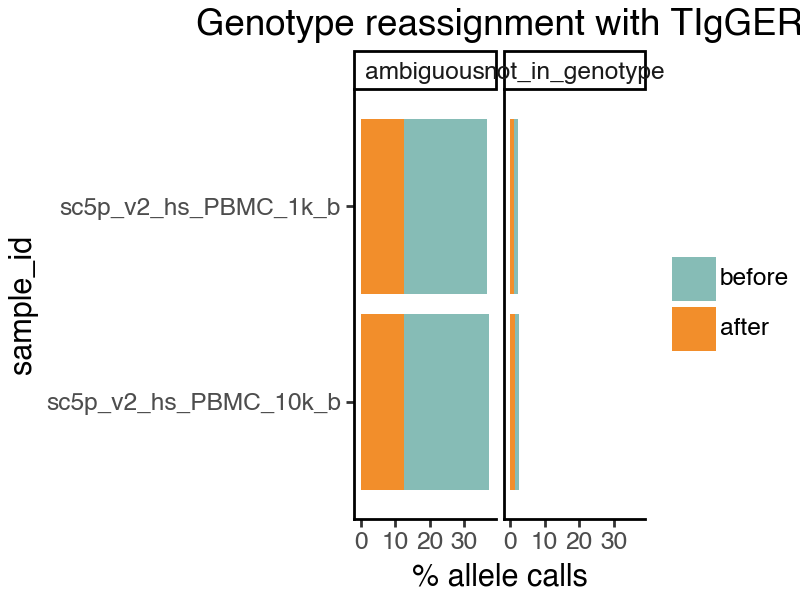

Writing out to individual folders : 100%|██████████| 2/2 [00:00<00:00,  3.78it/s]


In [5]:
# reassigning alleles on the first set of samples
ddl.pp.reassign_alleles(
    samples[:2], combined_folder="tutorial_scgp1", filename_prefix="filtered"
)

Processing data file(s) :   0%|          | 0/2 [00:00<?, ?it/s]

  START> ParseDb
COMMAND> select
   FILE> filtered_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IGH
  REGEX> True

PROGRESS> 13:32:26 |####################| 100% (1,853) 0.0 min

   OUTPUT> filtered_contig_igblast_db-pass_heavy_parse-select.tsv
  RECORDS> 1853
 SELECTED> 837
DISCARDED> 1016
      END> ParseDb



Processing data file(s) :  50%|█████     | 1/2 [00:00<00:00,  1.23it/s]

  START> ParseDb
COMMAND> select
   FILE> filtered_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IG[LK]
  REGEX> True

PROGRESS> 13:32:26 |####################| 100% (1,853) 0.0 min

   OUTPUT> filtered_contig_igblast_db-pass_light_parse-select.tsv
  RECORDS> 1853
 SELECTED> 1016
DISCARDED> 837
      END> ParseDb

  START> ParseDb
COMMAND> select
   FILE> filtered_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IGH
  REGEX> True

PROGRESS> 13:32:27 |####################| 100% (2,991) 0.0 min

   OUTPUT> filtered_contig_igblast_db-pass_heavy_parse-select.tsv
  RECORDS> 2991
 SELECTED> 1332
DISCARDED> 1659
      END> ParseDb



Processing data file(s) : 100%|██████████| 2/2 [00:01<00:00,  1.18it/s]

  START> ParseDb
COMMAND> select
   FILE> filtered_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IG[LK]
  REGEX> True

PROGRESS> 13:32:27 |####################| 100% (2,991) 0.0 min

   OUTPUT> filtered_contig_igblast_db-pass_light_parse-select.tsv
  RECORDS> 2991
 SELECTED> 1659
DISCARDED> 1332
      END> ParseDb

      Reassigning alleles



Reverting 65 sequence(s) whose V gene family is absent from the inferred genotype.


null device 
          1 
     START> CreateGermlines
      FILE> tutorial_scgp2_heavy_igblast_db-pass_genotyped.tsv
GERM_TYPES> dmask
 SEQ_FIELD> sequence_alignment
   V_FIELD> v_call_genotyped
   D_FIELD> d_call
   J_FIELD> j_call
    CLONED> False

PROGRESS> 13:32:46 |####################| 100% (2,169) 0.0 min

 OUTPUT> tutorial_scgp2_heavy_igblast_db-pass_genotyped_germ-pass.tsv
RECORDS> 2169
   PASS> 2131
   FAIL> 38
    END> CreateGermlines

     START> CreateGermlines
      FILE> tutorial_scgp2_light_igblast_db-pass.tsv
GERM_TYPES> dmask
 SEQ_FIELD> sequence_alignment
   V_FIELD> v_call
   D_FIELD> d_call
   J_FIELD> j_call
    CLONED> False

PROGRESS> 13:32:48 |####################| 100% (2,675) 0.0 min

 OUTPUT> tutorial_scgp2_light_igblast_db-pass_germ-pass.tsv
RECORDS> 2675
   PASS> 2675
   FAIL> 0
    END> CreateGermlines



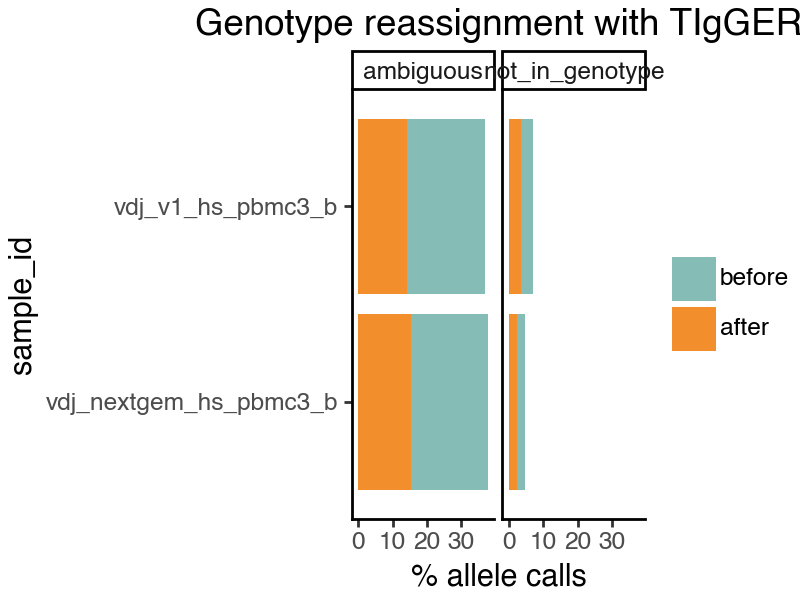

Writing out to individual folders : 100%|██████████| 2/2 [00:00<00:00,  2.22it/s]


In [6]:
# reassigning alleles on the second set of samples
ddl.pp.reassign_alleles(
    samples[2:], combined_folder="tutorial_scgp2", filename_prefix="filtered"
)

We can see that most of the original ambiguous V calls have now been corrected and only a few remain.

<div class="alert alert-info">
    
Note
    
Similar to above, if you you can specify the path to the folder containing the fasta files accordingly:

```python
ddl.pp.reassign_alleles(samples[2:], combined_folder='tutorial_scgp2', germline="database/germlines/imgt/human/vdj", filename_prefix="filtered")
```
</div>

## Step 4: Assigning constant region calls

Cell Ranger's annotation files provides a *c_gene* column, but rather than simply relying on Cell Ranger's annotation, it is common to use *[immcantation-presto's MaskPrimers.py](https://presto.readthedocs.io/en/version-0.5.3---license-change/tools/MaskPrimers.html)* with a custom primer list. 

As an alternative, `dandelion` includes a pre-processing function, `pp.assign_isotypes`, to use *blastn* to annotate constant region calls for all contigs and retrieves the call, merging it with the tsv files. This function will overwrite the output from previous steps and add a *c_call* column at the end, or replace the existing column if it already exists. The Cell Ranger calls are returned as `c_call_10x`.

Further, to deal with incorrect constant gene calls due to insufficient length, a pairwise alignment will be run against [curated sequences](https://immunology.sciencemag.org/content/6/56/eabe6291) that were deemed to be highly specific in distinguishing `IGHA1` vs `IGHA2`, and `IGHG1` to `IGHG4`. I have also curated sets of sequences that should help deal with `IGLC3/6/7` as these are problematic too. If there is insufficient info, the `c_call` will be returned as a combination of the most aligned sets of sequences. Because of how similar the lambda light chains are, extremely ambiguous calls (only able to map to a common sequence across the light chains) will be returned as `IGLC`. This typically occurs when the constant sequence is very short. Those that have equal alignment scores between `IGLC3/6/7` sequences and the common sequence will be returned as a concatenated call; for example, a contig initially annotated as `IGLC3` will be returned as `IGLC,IGLC3`. 

<div class="alert alert-info">

Note

The curated sequences can be updated/replaced with a dict-of-dict-of-dict style dictionary via the option `correction_dict`. The provided dictionary should be a nested dictionary like the following:
```python
primer_dict = {
    'IGHG':{
        'IGHG1':'GCCTCCACCAAGGGCCCATCGGTCTTCCCCCTGGCACCCTCCTCCAAGAGCACCTCTGGGGGCACAGCGGCCCTGGGC',
        'IGHG2':'GCCTCCACCAAGGGCCCATCGGTCTTCCCCCTGGCGCCCTGCTCCAGGAGCACCTCCGAGAGCACAGCGGCCCTGGGC',
        'IGHG3':'GCTTCCACCAAGGGCCCATCGGTCTTCCCCCTGGCGCCCTGCTCCAGGAGCACCTCTGGGGGCACAGCGGCCCTGGGC',
        'IGHG4':'GCTTCCACCAAGGGCCCATCCGTCTTCCCCCTGGCGCCCTGCTCCAGGAGCACCTCCGAGAGCACAGCCGCCCTGGGC'}}
```

The key for the first level of the dictionary is used for searching whether the string pattern exists in the `c_call`, and the second level holds the dictionary for the the reference sequences to align to. The keys in the second level are used for replacing the existing `c_call` annotation if it is returned with the highest alignment score. The function currently only accepts 2-4 reference sequences for the pairwise alignment.
</div>

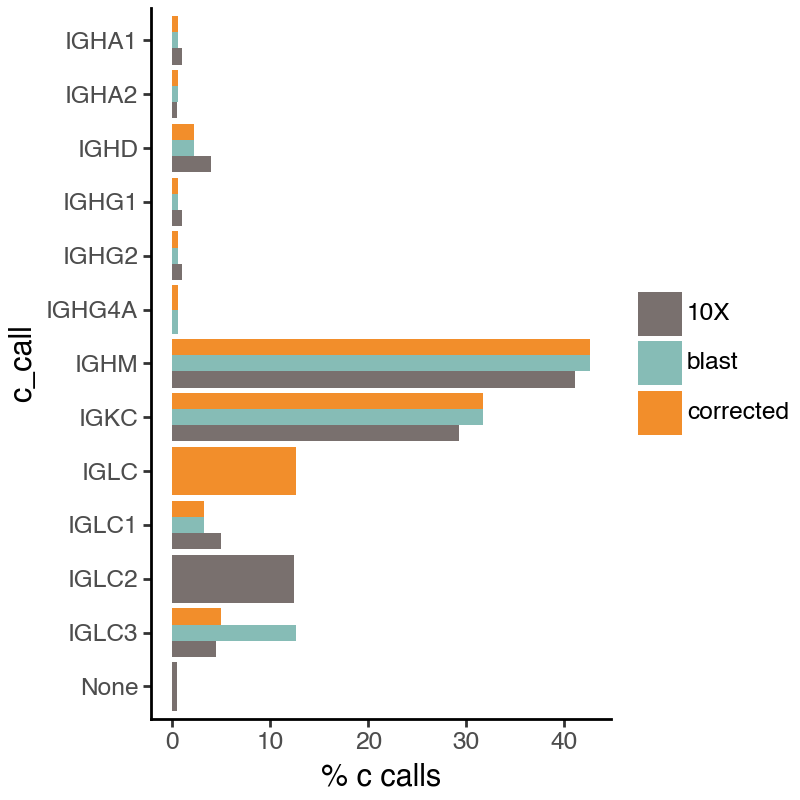

/Users/uqztuong/Documents/GitHub/dandelion/src/dandelion/base/preprocessing/_preprocessing.py:4306: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/Users/uqztuong/Documents/GitHub/dandelion/src/dandelion/base/preprocessing/_preprocessing.py:4521: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


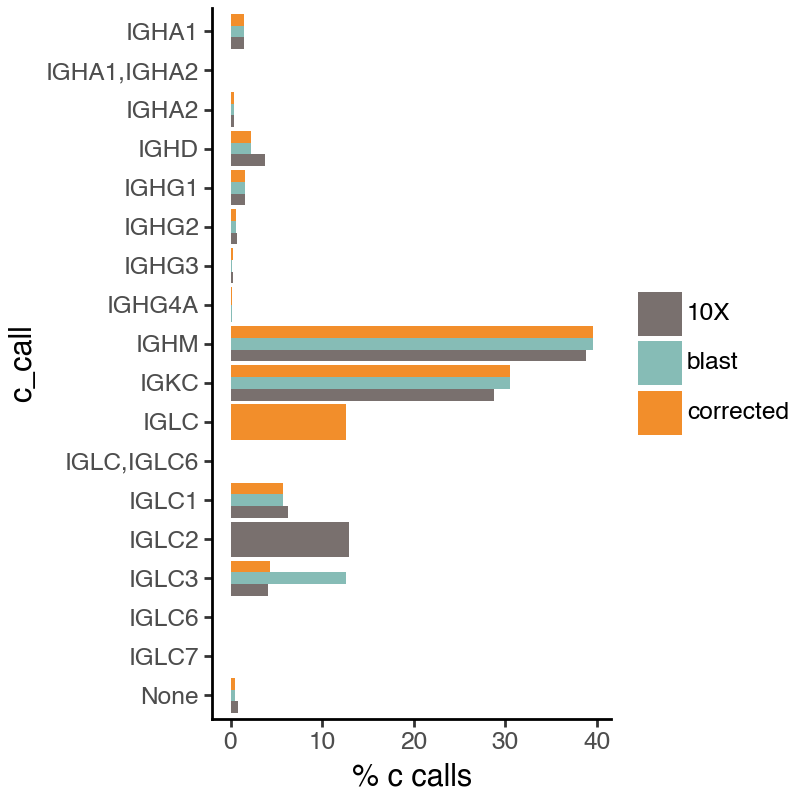

/Users/uqztuong/Documents/GitHub/dandelion/src/dandelion/base/preprocessing/_preprocessing.py:4306: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


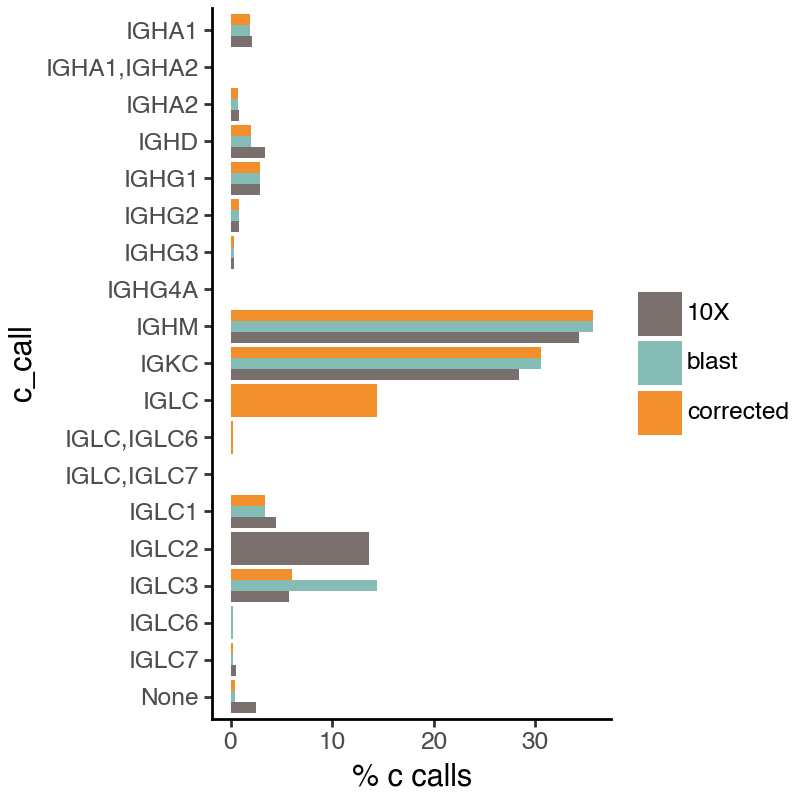

/Users/uqztuong/Documents/GitHub/dandelion/src/dandelion/base/preprocessing/_preprocessing.py:4306: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


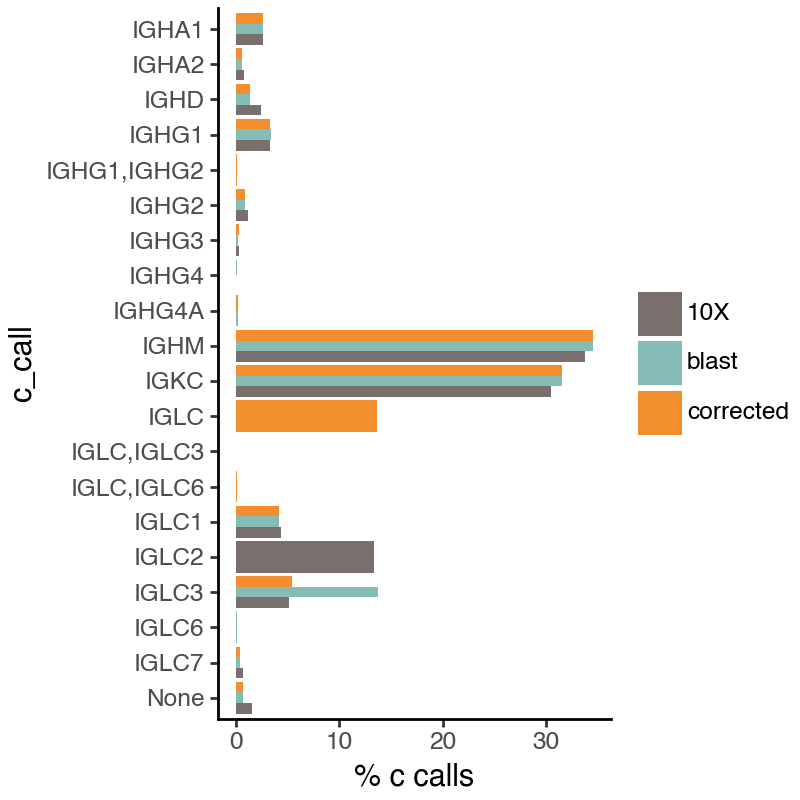

/Users/uqztuong/Documents/GitHub/dandelion/src/dandelion/base/preprocessing/_preprocessing.py:4306: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [7]:
ddl.pp.assign_isotypes(samples, filename_prefix="filtered")

<div class="alert alert-info">

Note
    
Should you want to use a different reference fasta file for this step, run with the following option:

```python
ddl.pp.assign_isotypes(samples, blastdb="path/to/custom_BCR_constant.fasta")
```

The default option will return a summary plot that can be disabled with `plot=False`.
</div>
    
Finally, it's worthwhile to manually check the the sequences for constant calls returned as IGHA1-2, IGHG1-4 and the light chains and manually correct them if necessary.

## Step 5: Quantify mutations *(optional)*.

At this stage, with all the necessary columns in the files, you can quantify the basic mutational load with `pp.quantify_mutations`, a wrapper of `SHaZaM`'s basic mutational analysis in R [[Gupta2015]](https://academic.oup.com/bioinformatics/article/31/20/3356/195677), before subsequent analyses. This will be covered again later in the `Calculating diversity and mutation` section.

In [8]:
from tqdm import tqdm

# quantify mutations
for s in tqdm(samples, desc="Basic mutational load analysis "):
    filePath = s + "/dandelion/filtered_contig_dandelion.tsv"
    ddl.pp.quantify_mutations(filePath)
    # or dandelion.external.immcantation.shazam.quantify_mutations(filePath)

Basic mutational load analysis : 100%|██████████| 4/4 [00:19<00:00,  4.98s/it]
